<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit7/Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Polynomial terms allow a model to capture curved patterns and more realistic relationships, which improves how well the model fits real-world data.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

You might not want to include a polynomial element because it can make the model too complex and lead to overfitting.

Higher-degree polynomials can also create unrealistic oscillations between data points and make the model harder to interpret. In some cases, a simple linear model explains the relationship well enough.

**Task3**:

What's the point of using b splines?

B-splines are used to model complex curved relationships without relying on  high-degree polynomials. Instead, they fit several low-degree polynomials to different sections of the data and connect them smoothly at points called knots. This makes the model flexible and able to follow complicated trends.


**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

Gaussian Process kind of draws many smooth curves that could fit the data and then average them in a way that favors curves that match the observed points . This makes it useful for modeling complex relationships. It also has input for uncertainty and shows them.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [1]:
!pip install preliz
!pip install bambi

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [15]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
model_poly = bmb.Model("height ~ poly(weight, degree=7)", howell, family="gaussian")
idata_poly = model_poly.fit()

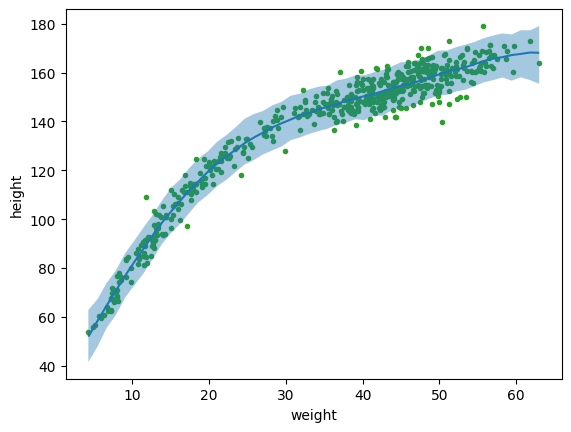

In [20]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly, idata_poly, "weight", pps=True)
#raw data
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [ ]:
num_knots = 6
knots = np.linspace(howell.weight.min(), howell.weight.max(), num_knots+2)[1:-1]
model_spline = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howell, family="gaussian")
idata_spline = model_spline.fit()

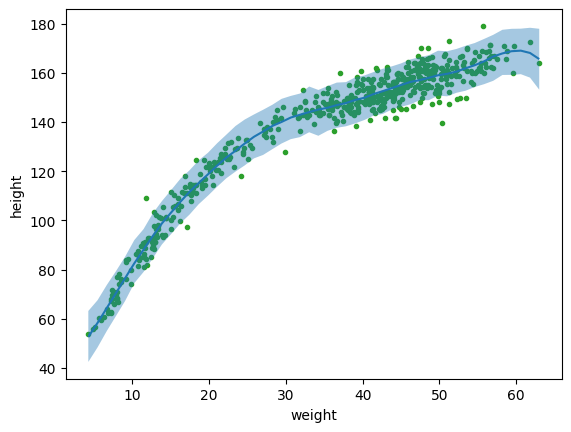

In [27]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "weight", pps= True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [29]:
height = howell["height"].values
weight = howell["weight"].values[:,None]

In [30]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [31]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 24], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 8.0


In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(weight))
}

priors = {
    "hsgp(weight, m=168, c=8.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("height ~ 0 + hsgp(weight, m=168, c=8.0)", howell, family="gaussian", priors=priors)
idata_hsb = model_hsb.fit()

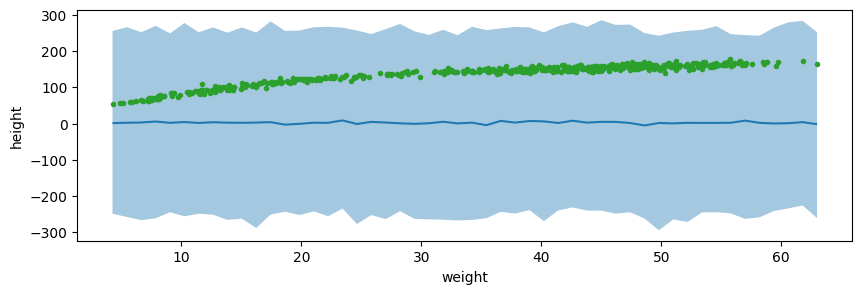

In [33]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["weight"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["weight"].values, howell["height"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

I learned that gaussian processes can use uncertainty in the input. This uncertainty in the inputs is used through covariance function, which leads to more realistic posterior predictions

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

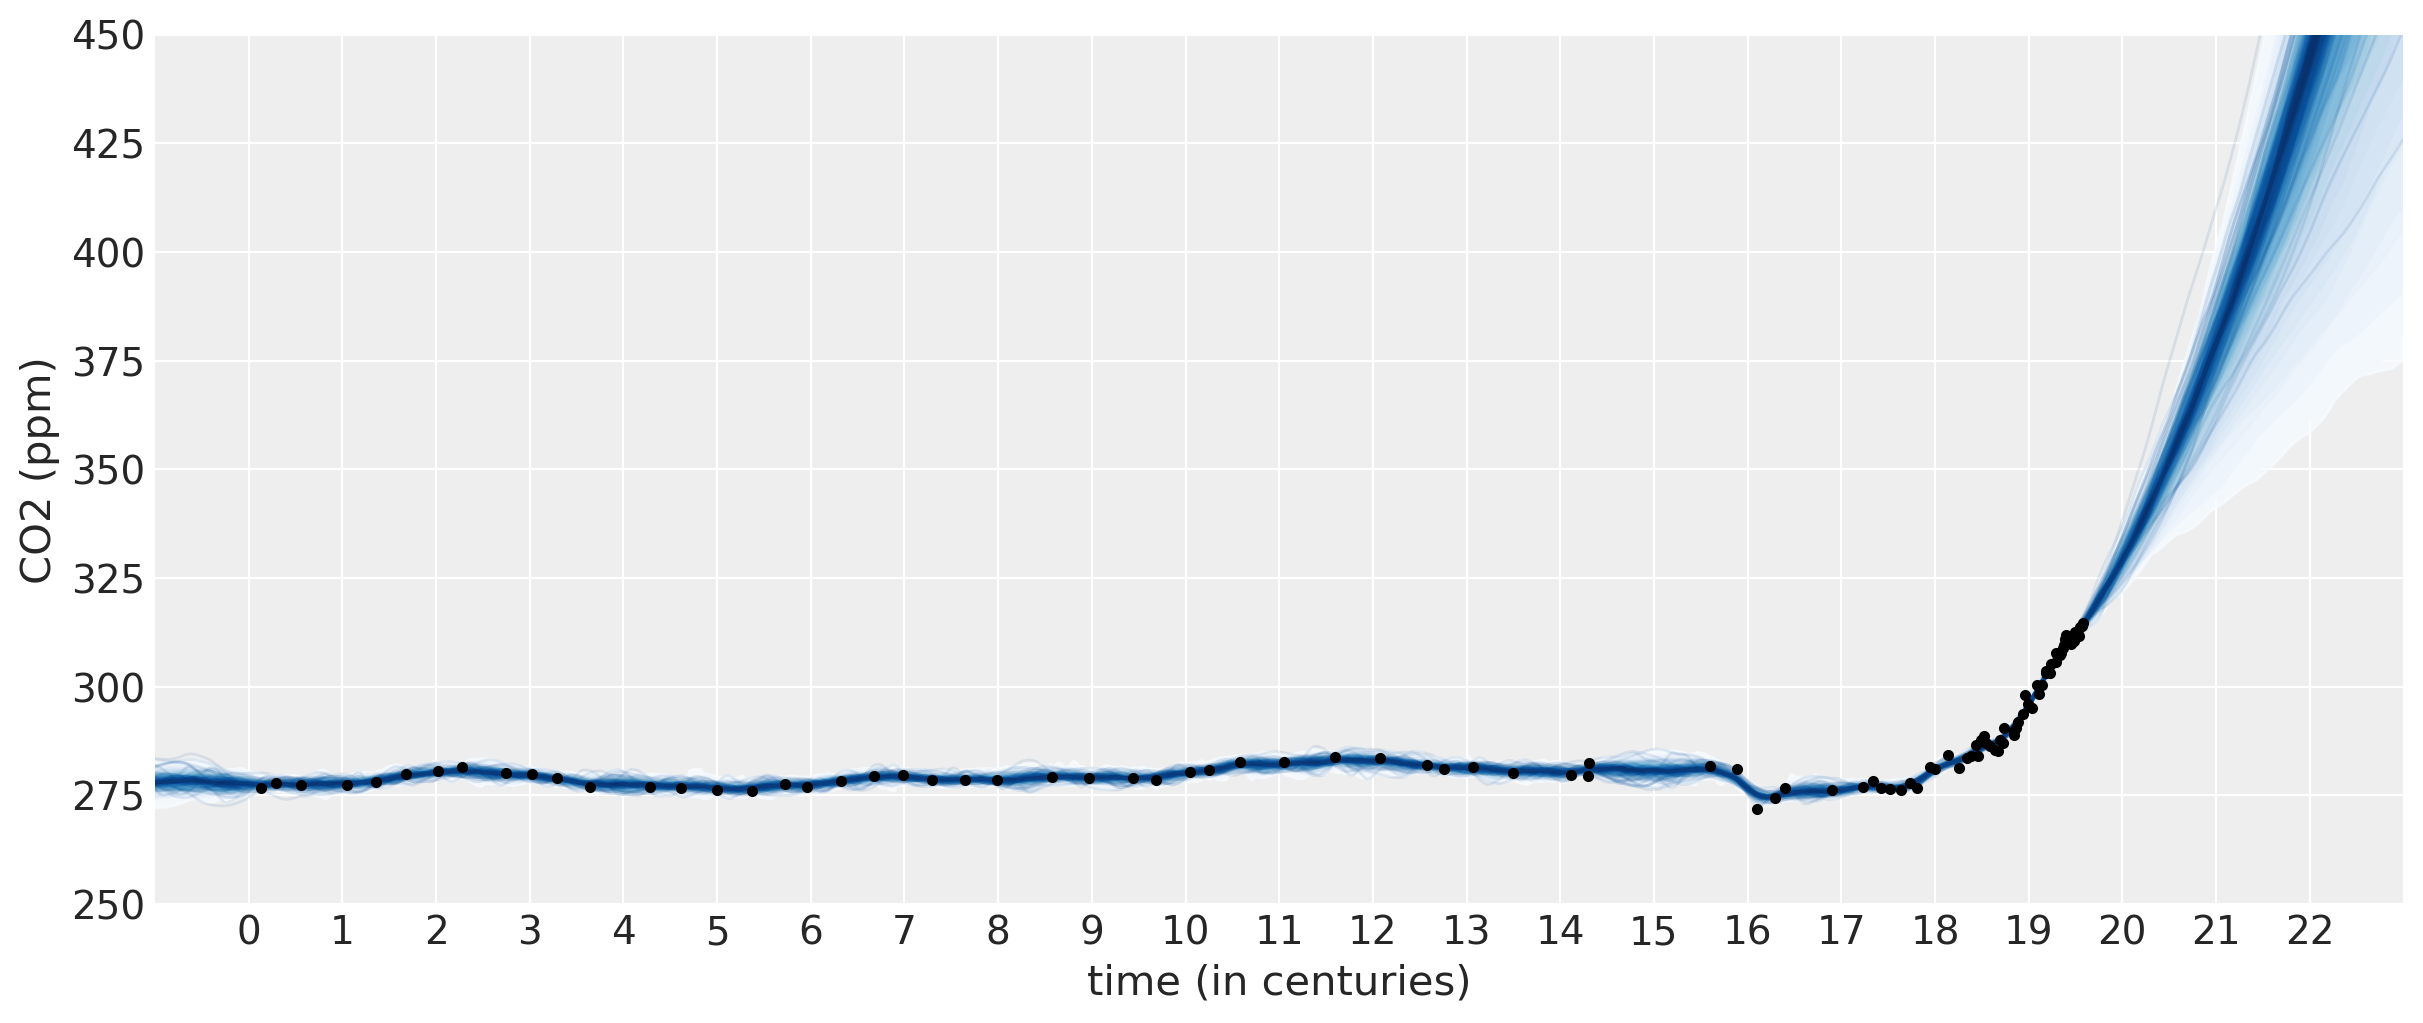

I liked this visualization because you can see how it shows both data and the uncertainty factor. the density of the lines shows how probable it is and it gets less and less probable as time goes on. It fans out.